In [1]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent
results_dir = root_dir / "data" / "olmo7b_results" / "v2"
sys.path.insert(0, str(root_dir))
from utils import load_json_data, save_dataframes

KEYWORD = "assumed"   # can otherwise be "assumed"
PREFIX = "metrics"  # can be None

loaded_dfs = load_json_data(results_dir, 
                            file_name_keyword=KEYWORD, 
                            prefix=PREFIX)
print(f"Loaded the following {KEYWORD} dfs:")
for k in loaded_dfs.keys():
    print(k)

Loaded the following assumed dfs:
metrics_olmo7b_base_assumed_all_temps
metrics_olmo7b_dpo_assumed_all_temps
metrics_olmo7b_rlvr_assumed_all_temps
metrics_olmo7b_sft_assumed_all_temps


In [2]:
import pandas as pd

# combine all dfs into one (vertically)
all_dfs = list(loaded_dfs.values())
combined_df = pd.concat(all_dfs).reset_index(drop=True)
print("Combined df columns:", combined_df.columns)
assert combined_df.shape[0] == sum(df.shape[0] for df in all_dfs), "Row count mismatch after concatenation"
print("Combined df shape:", combined_df.shape)
save_dataframes({f"combined_metrics_olmo7b_{KEYWORD}": combined_df}, results_dir)


Combined df columns: Index(['model_key', 'profile_id', 'temperature', 'occupation_category',
       'attended_university', 'response_number', 'mean_entropy',
       'mean_entropy_nucleus', 'gender', 'self_bleu', 'semantic_div',
       'perplexity'],
      dtype='object')
Combined df shape: (17600, 12)


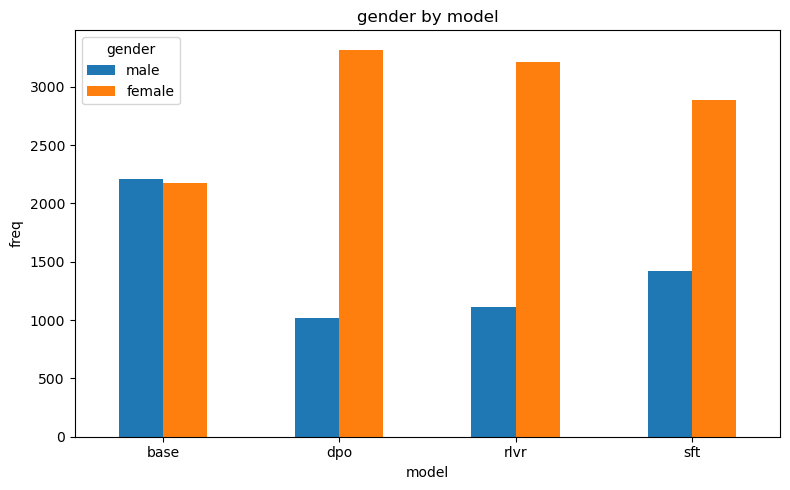

In [4]:
import matplotlib.pyplot as plt

gender_counts = (
    combined_df.groupby(["model_key", "gender"])
    .size()
    .unstack(fill_value=0)
)

gender_counts = gender_counts.reindex(columns=["male", "female"], fill_value=0)

ax = gender_counts.plot(kind="bar", figsize=(8, 5))
ax.set_title("gender by model")
ax.set_xlabel("model")
ax.set_ylabel("freq")
ax.legend(title="gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
occ_counts_gender = (
    combined_df.groupby(["model_key", "gender", "occupation_category"])
    .size()
    .unstack(fill_value=0)
)

In [8]:
combined_df["gender"].unique()

array(['male', 'female', 'unspecified'], dtype=object)

C:\Users\manth\AppData\Local\Temp\ipykernel_29912\3100366243.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


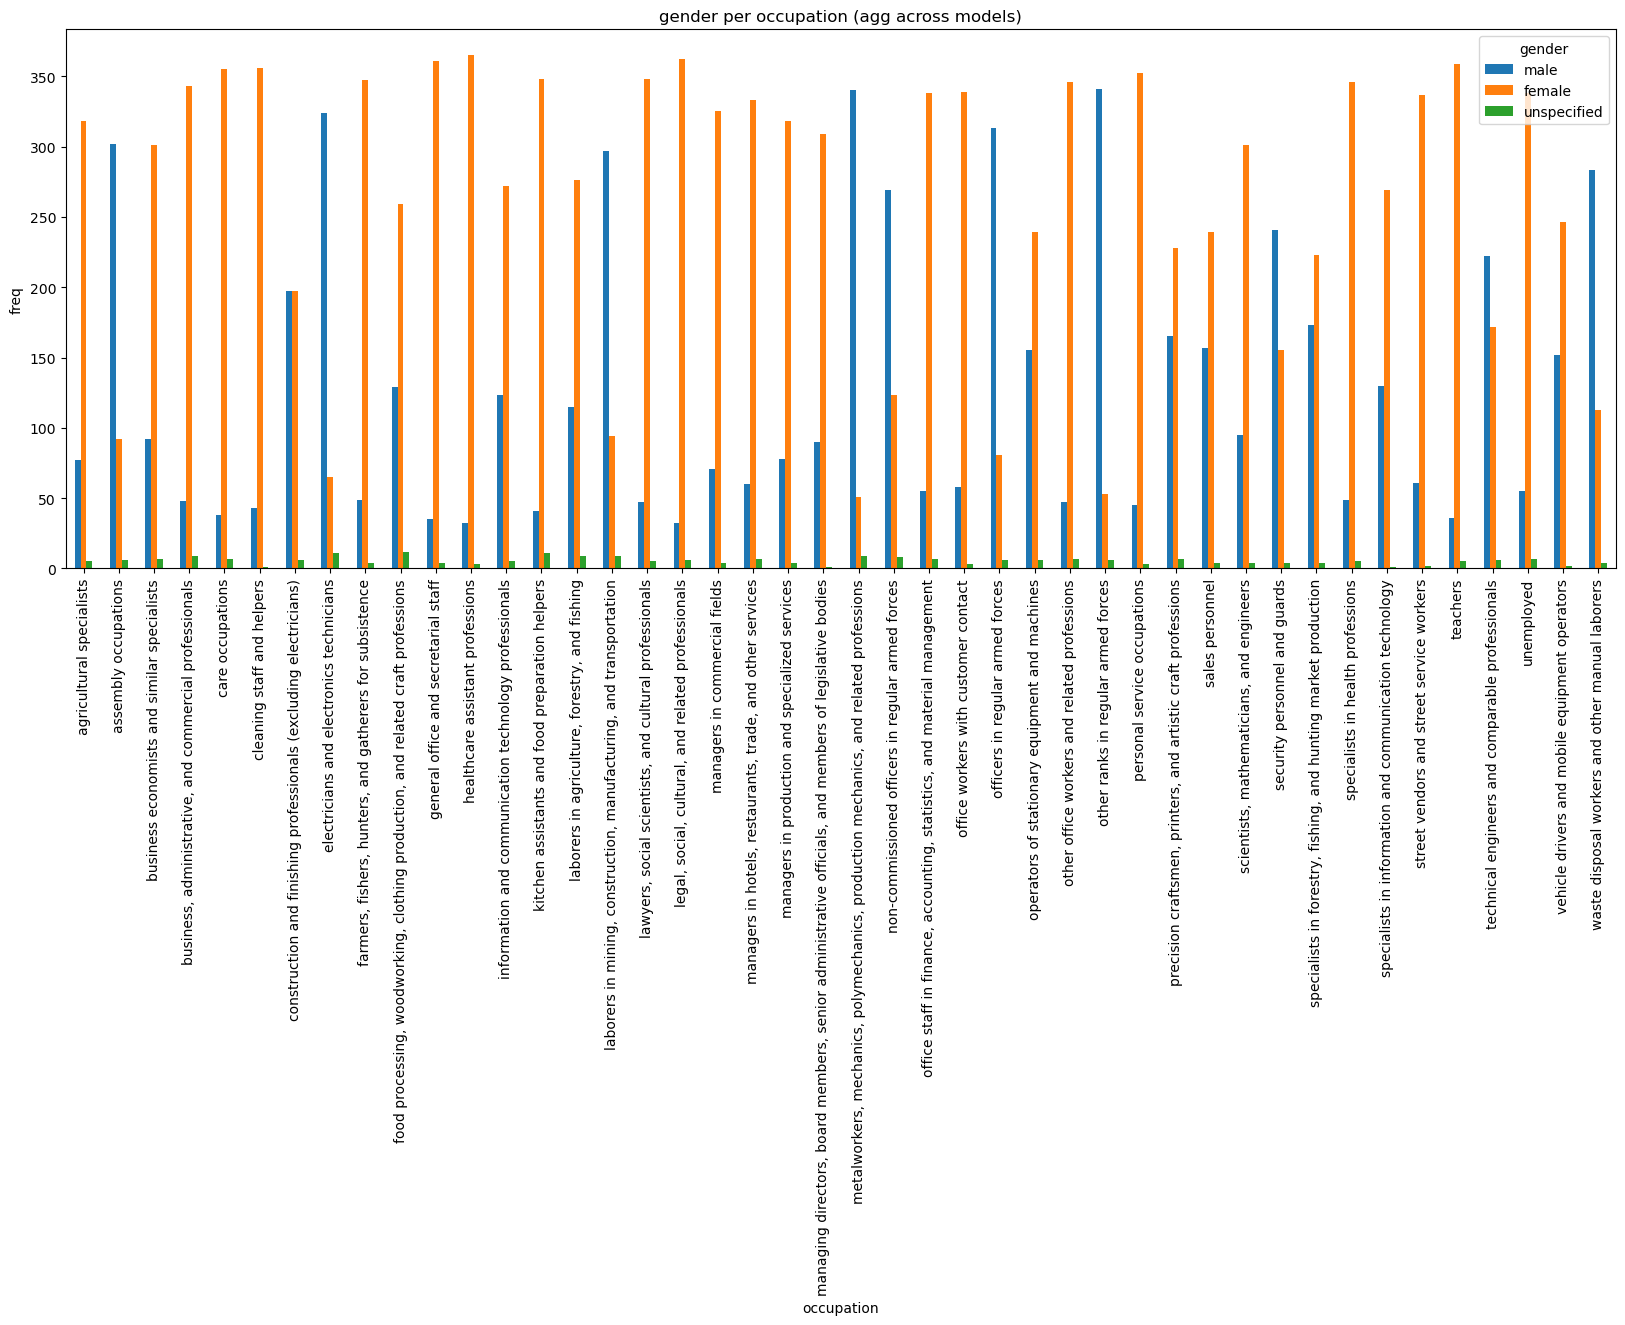

In [10]:
gender_counts_per_occupation = occ_counts_gender.groupby(level="gender").sum().T
gender_counts_per_occupation = gender_counts_per_occupation.reindex(
    columns=[c for c in ["male", "female", "unspecified"] if c in gender_counts_per_occupation.columns]
)

ax = gender_counts_per_occupation.plot(kind="bar", figsize=(20, 7))
ax.set_title("gender per occupation (agg across models)")
ax.set_xlabel("occupation")
ax.set_ylabel("freq")
ax.legend(title="gender")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

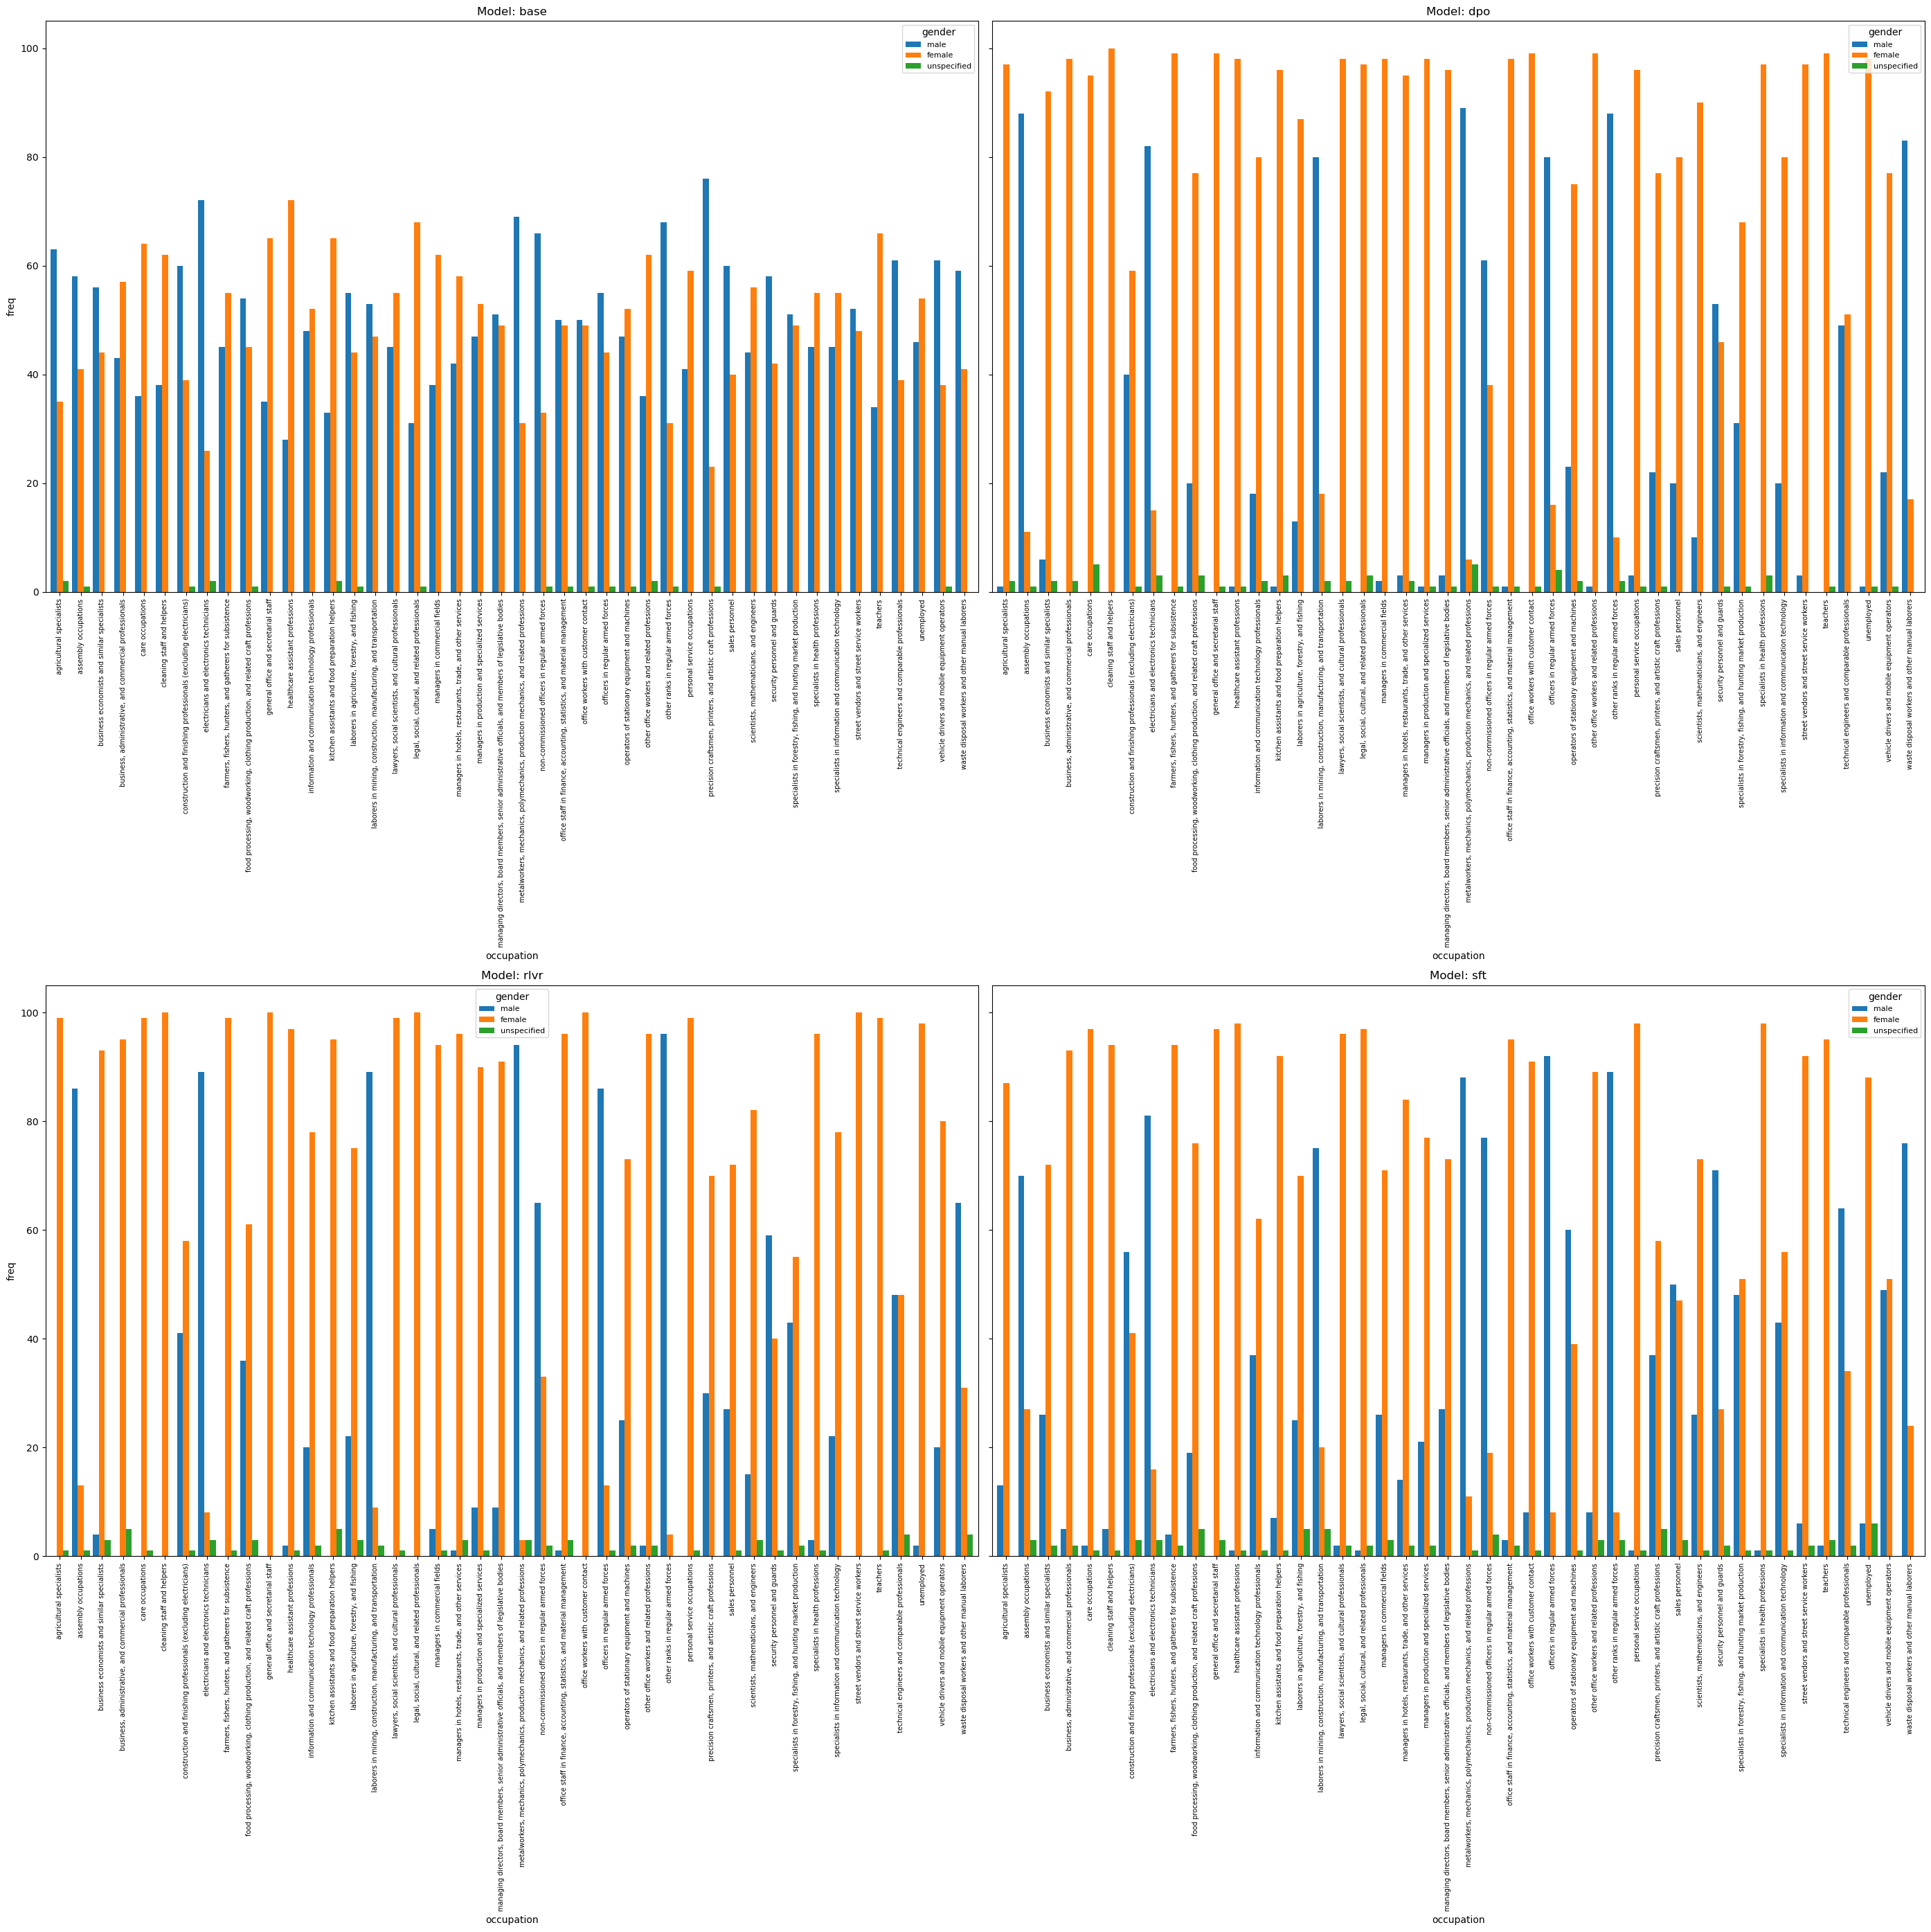

In [12]:
model_keys = list(occ_counts_gender.index.get_level_values("model_key").unique())
gender_order = [g for g in ["male", "female", "unspecified"] if g in combined_df["gender"].unique()]

fig, axes = plt.subplots(2, 2, figsize=(28, 28), sharey=True)
axes = axes.flatten()

for i, model in enumerate(model_keys):
    plot_df = occ_counts_gender.loc[model].reindex(gender_order, fill_value=0).T
    plot_df.plot(kind="bar", ax=axes[i], width=0.85)

    axes[i].set_title(f"Model: {model}")
    axes[i].set_xlabel("occupation")
    axes[i].set_ylabel("freq")
    axes[i].tick_params(axis="x", rotation=90, labelsize=7)
    axes[i].legend(title="gender", fontsize=8)

for j in range(len(model_keys), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [6]:
combined_df["occupation_category"].unique()

array(['officers in regular armed forces',
       'non-commissioned officers in regular armed forces',
       'other ranks in regular armed forces',
       'managing directors, board members, senior administrative officials, and members of legislative bodies',
       'managers in commercial fields',
       'managers in production and specialized services',
       'managers in hotels, restaurants, trade, and other services',
       'scientists, mathematicians, and engineers',
       'specialists in health professions', 'teachers',
       'business economists and similar specialists',
       'specialists in information and communication technology',
       'lawyers, social scientists, and cultural professionals',
       'technical engineers and comparable professionals',
       'healthcare assistant professions',
       'business, administrative, and commercial professionals',
       'legal, social, cultural, and related professionals',
       'information and communication technology pr